<a href="https://colab.research.google.com/github/Azyur-i/CS182-03/blob/main/FA5/C01FA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FA5: Building Naive Bayes Model
By: Heughric Fernando and Jan Christian Diesta (Group 7)

# Importing and Loading the Dataset

In [16]:
import numpy as np
import pandas as pd
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

with zipfile.ZipFile('spambase.zip', 'r') as z:
    with z.open('spambase.data') as f:
        names = [
            'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
            'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
            'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
            'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
            'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
            'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
            'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
            'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
            'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
            'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(',
            'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'capital_run_length_average',
            'capital_run_length_longest', 'capital_run_length_total', 'label'
        ]
        df = pd.read_csv(f, names=names)

- This is where we do our usual imports for needed packages to make our code work
- We also manually map the attribute names to the columns so we can actually identify features like word frequency or character counts.
- It also uses the zipfile library to read the raw data into memory without unzipping it to the disk.

# Preprocessing the Data from the Dataset

In [17]:
X = df.drop('label', axis=1).values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

- We manually map the attribute names to the columns so we can identify features like word frequency, then split the data into 70% training and 30% testing sets.

# Create our Model

In [18]:
class NaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        for idx, c in enumerate(self.classes):
            prior = np.log(self._priors[idx])
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posteriors.append(prior + posterior)

        return self.classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx] + 1e-9
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

nb = NaiveBayes()
nb.fit(X_train, y_train)
predictions = nb.predict(X_test)

/tmp/ipython-input-2886445703.py:26: RuntimeWarning: divide by zero encountered in log
  posterior = np.sum(np.log(self._pdf(idx, x)))


- The fit method calculates the mean and variance for every feature  to understand the statistical "shape" of spam versus non-spam emails.
- We store these statistics in matrices so we can quickly access them later when we need to make a decision on new data.
- The predict method then uses these learned statistics and a Gaussian probability formula to classify the new test emails based on which class they most statistically resemble.

# Model Visualization and Evaluation

Detailed Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.94      0.73      0.82       804
        Spam       0.71      0.94      0.81       577

    accuracy                           0.82      1381
   macro avg       0.83      0.83      0.82      1381
weighted avg       0.85      0.82      0.82      1381

Overall Model Accuracy: 81.75%


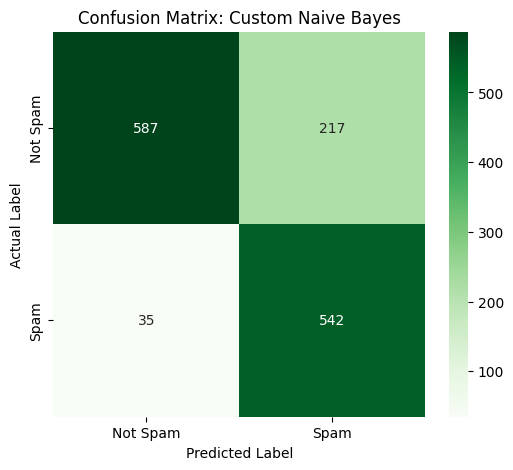

In [19]:
print("Detailed Classification Report:")
print(classification_report(y_test, predictions, target_names=['Not Spam', 'Spam']))

acc = accuracy_score(y_test, predictions)
print(f"Overall Model Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Custom Naive Bayes')
plt.show()

- We evaluate the model using a classification report and visualize the errors with a confusion matrix.
- The report includes the usual Precision, Recall, and F1-score and accuracy.
- The heatmap visualization allows us to instantly spot "False Positives" versus "False Negatives."

# Model Discussion

The custom Gaussian Naive Bayes model achieves an overall accuracy of about 82 percent on the test set, with an error rate close to 18 percent. The dataset contains 4601 emails with 57 numeric features, and the 70 to 30 split results in about 1380 test samples.

The confusion matrix shows most spam emails correctly classified, with a noticeable number of false positives where non spam emails are predicted as spam. Precision and recall values remain balanced across classes, indicating stable performance even with simple probability estimates.

Features such as word_freq_free, word_freq_money, and char_freq_$ show higher average values in spam emails, while legitimate emails maintain lower frequencies. Capitalization related features like capital_run_length_average and capital_run_length_longest also display larger values in spam messages.

# References

AssemblyAI. (2022, September 17). How to implement Naive Bayes from scratch with Python. YouTube. https://www.youtube.com/watch?v=TLInuAorxqE

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.

McKinney, W. (2010). Data Structures for Statistical Computing in Python. Proceedings of the 9th Python in Science Conference, 51–56.

Murphy, K. P. (2012). Machine learning: A probabilistic perspective. MIT Press.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Van Rossum, G., & Drake, F. L. (2009). Python 3 Reference Manual. Scotts Valley, CA: CreateSpace.